# TempusClusterAnalysis
Andrew E. Davidson aedaivds@ucsc.edu 03/04/25

Copyright (c) 2020-2023, Regents of the University of California All rights reserved. https://polyformproject.org/licenses/noncommercial/1.0.0

ref:  
- intraExtraRNA_POC/jupyterNotebooks/elife/lungCancer/elifeLungCancerNon-CodingBiomarkerRandomForest.ipynb
- extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/clusterAnalysis.html
- extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/lungCancer/lungCancerPCA_ClusterAnalysis.ipynb shape : (224,7655)
- extraCellularRNA/deconvolutionAnalysis/jupyterNotebooks/randomForestGeneSignatureDeconvolution.ipynb

In [1]:
import ipynbname

# use display() to print an html version of a data frame
# useful if dataFrame output is not generated by last like of cell
from IPython.display import display
import joblib
import logging
import matplotlib.pyplot as plt 
import numpy as np
import os
import pandas as pd
# display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler #, StandardScaler # LabelEncoder, 

import sys
import umap

/private/home/aedavids/miniconda3/envs/extraCellularRNA/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
notebookName = ipynbname.name()
notebookPath = ipynbname.path()
notebookDir = os.path.dirname(notebookPath)

outDir = f'{notebookDir}/{notebookName}.out'
#outDir = f'/private/groups/kimlab/aedavids/deconvolution/{notebookName}.out'
os.makedirs(outDir, exist_ok=True)
print(f'outDir:\n{outDir}')

# modelOutDir = os.path.join(outDir, "model")
# os.makedirs(modelOutDir, exist_ok=True)
# print(f'\nmodelOutDir ;\n{modelOutDir}')

imgOut = f'{outDir}/img'
os.makedirs(imgOut, exist_ok=True)
print(f'\nimgOut :\n{imgOut}')

loglevel = "INFO"
#loglevel = "WARN"
# logFMT = "%(asctime)s %(levelname)s [thr:%(threadName)s %(name)s %(funcName)s() line:%(lineno)s] [%(message)s]"
logFMT = "%(asctime)s %(levelname)s %(name)s %(funcName)s() line:%(lineno)s] [%(message)s]"
logging.basicConfig(format=logFMT, level=loglevel)    
logger = logging.getLogger(notebookName)

outDir:
/private/home/aedavids/extraCellularRNA/deconvolutionAnalysis/tempus/jupyterNotebooks/tempusClusterAnalysis.out

imgOut :
/private/home/aedavids/extraCellularRNA/deconvolutionAnalysis/tempus/jupyterNotebooks/tempusClusterAnalysis.out/img


In [3]:
# setting the python path allows us to run python scripts from using
# the CLI. 
ORIG_PYTHONPATH = os.environ['PYTHONPATH']
print(f'os.getcwd() : {os.getcwd()}')
# deconvolutionModules = notebookPath.parent.joinpath("../../../../deconvolutionAnalysis/python/")
deconvolutionModules = notebookPath.parent.joinpath("../../../deconvolutionAnalysis/python/")

print("deconvolutionModules: {}\n".format(deconvolutionModules))

PYTHONPATH = ORIG_PYTHONPATH + f':{deconvolutionModules}'
print("PYTHONPATH: {}\n".format(PYTHONPATH))

intraExtraRNA_POCModules=notebookPath.parent.joinpath("../../../python/src")
print("intraExtraRNA_POCModules: {}\n".format(intraExtraRNA_POCModules))

PYTHONPATH = PYTHONPATH + f':{intraExtraRNA_POCModules}'
print("PYTHONPATH: {}\n".format(PYTHONPATH))

########
os.environ["PYTHONPATH"] = PYTHONPATH
PYTHONPATH = os.environ["PYTHONPATH"]
print("PYTHONPATH: {}\n".format(PYTHONPATH))

# to be able to import our local python files we need to set the sys.path
# https://stackoverflow.com/a/50155834
sys.path.append( str(deconvolutionModules) )
sys.path.append( str(intraExtraRNA_POCModules) )
#print("\nsys.path:\n{}\n".format(sys.path))

os.getcwd() : /private/home/aedavids/extraCellularRNA/deconvolutionAnalysis/tempus/jupyterNotebooks
deconvolutionModules: /private/home/aedavids/extraCellularRNA/deconvolutionAnalysis/tempus/jupyterNotebooks/../../../deconvolutionAnalysis/python

PYTHONPATH: :/private/home/aedavids/extraCellularRNA/src:/private/home/aedavids/extraCellularRNA/deconvolutionAnalysis/tempus/jupyterNotebooks/../../../deconvolutionAnalysis/python

intraExtraRNA_POCModules: /private/home/aedavids/extraCellularRNA/deconvolutionAnalysis/tempus/jupyterNotebooks/../../../python/src

PYTHONPATH: :/private/home/aedavids/extraCellularRNA/src:/private/home/aedavids/extraCellularRNA/deconvolutionAnalysis/tempus/jupyterNotebooks/../../../deconvolutionAnalysis/python:/private/home/aedavids/extraCellularRNA/deconvolutionAnalysis/tempus/jupyterNotebooks/../../../python/src

PYTHONPATH: :/private/home/aedavids/extraCellularRNA/src:/private/home/aedavids/extraCellularRNA/deconvolutionAnalysis/tempus/jupyterNotebooks/../../.

In [4]:
aedwip = "/private/home/aedavids/extraCellularRNA/deconvolutionAnalysis/tempus/jupyterNotebooks"
x = f"{aedwip}/../../../deconvolutionAnalysis/python/plots"
! ls $x
x

doc  __init__.py  __pycache__  scatterPlots.py	test  upsetPlots.py


'/private/home/aedavids/extraCellularRNA/deconvolutionAnalysis/tempus/jupyterNotebooks/../../../deconvolutionAnalysis/python/plots'

# Load Tempus Data
Select the control and undiluted samples

In [5]:
tempusCountPath = "/private/groups/kimlab/data/tempus/illumina/20241107/create/annotated_norm_counts.csv"
tempusCountDF = pd.read_csv(tempusCountPath)

In [6]:
print(f'tempusCountPath.shape : {tempusCountDF.shape}')
tempusCountDF.iloc[0:5, 0:6]

tempusCountPath.shape : (76539, 38)


,gene_id,gene_name,gene_biotype,SLDK3_T1_100_S1_L007,SLDK3_T1_100K_S2_L007,SLDK3_T1_10K_S3_L007
0,(A)n,(A)n,Microsatellite,0.545009,1.987324,0.569635
1,(AAA)n,(AAA)n,Microsatellite,0.000000,0.000000,0.000000
2,(AAAAAAC)n,(AAAAAAC)n,Microsatellite,0.000000,0.000000,0.000000
3,(AAAAAAG)n,(AAAAAAG)n,Microsatellite,0.000000,0.000000,0.000000
4,(AAAAAAT)n,(AAAAAAT)n,Microsatellite,0.000000,0.000000,0.000000


In [7]:
tempusMetaDataPath = "/private/groups/kimlab/data/tempus/illumina/20241107/raw/metaDataWithHeader_BUG_FIX.csv"
tempusMetaDF = pd.read_csv(tempusMetaDataPath)
print(f'tempusCountPath.shape : {tempusCountDF.shape}')
tempusCountDF.iloc[0:5, 0:6]

tempusCountPath.shape : (76539, 38)


,gene_id,gene_name,gene_biotype,SLDK3_T1_100_S1_L007,SLDK3_T1_100K_S2_L007,SLDK3_T1_10K_S3_L007
0,(A)n,(A)n,Microsatellite,0.545009,1.987324,0.569635
1,(AAA)n,(AAA)n,Microsatellite,0.000000,0.000000,0.000000
2,(AAAAAAC)n,(AAAAAAC)n,Microsatellite,0.000000,0.000000,0.000000
3,(AAAAAAG)n,(AAAAAAG)n,Microsatellite,0.000000,0.000000,0.000000
4,(AAAAAAT)n,(AAAAAAT)n,Microsatellite,0.000000,0.000000,0.000000


In [8]:
selectRows = tempusMetaDF.loc[:, "category"].isin( ['Control', 'UD'] )
tempusSamplesMetaDF = tempusMetaDF.loc[selectRows, :]
print(f'tempusSamplesMetaDF.shape : {tempusSamplesMetaDF.shape}' )
display( tempusSamplesMetaDF)
sampleIds = tempusSamplesMetaDF.loc[:, "sample_id"].to_list()

tempusSamplesMetaDF.shape : (10, 2)


,sample_id,category
5,SLDK3_T1_Control_S6_L007,Control
6,SLDK3_T1_UD_S7_L007,UD
12,SLDK3_T2_Control_S13_L007,Control
13,SLDK3_T2_UD_S14_L007,UD
19,SLDK3_T3_Control_S20_L007,Control
20,SLDK3_T3_UD_S21_L007,UD
26,SLDK3_T5_Control_S27_L007,Control
27,SLDK3_T5_UD_S28_L007,UD
33,SLDK3_T6_Control_S34_L007,Control
34,SLDK3_T6_UD_S35_L007,UD


In [9]:
def selectSamples( 
                    countDF : pd.DataFrame,
                    metaDataDF : pd.DataFrame) -> pd.DataFrame :
    '''
    TODO
    '''
    sampleIds = metaDataDF.loc[:, "sample_id"].to_list()
    retDF = countDF.loc[:, ['gene_id'] + sampleIds]

    return retDF

tempusSampleCountsDF = selectSamples(tempusCountDF, tempusSamplesMetaDF) 
print(f'tempusSampleCountsDF.shape : {tempusSampleCountsDF.shape}')
tempusSampleCountsDF.iloc[0:5, 0:4]

tempusSampleCountsDF.shape : (76539, 11)


,gene_id,SLDK3_T1_Control_S6_L007,SLDK3_T1_UD_S7_L007,SLDK3_T2_Control_S13_L007
0,(A)n,0.0,51.916383,1.240713
1,(AAA)n,0.0,0.000000,0.000000
2,(AAAAAAC)n,0.0,0.000000,0.000000
3,(AAAAAAG)n,0.0,0.000000,0.000000
4,(AAAAAAT)n,0.0,0.000000,0.000000


In [10]:
nRows, nCols = tempusSampleCountsDF.shape
# skip the 'gene_id column'
XDF = tempusSampleCountsDF.iloc[:, 1:nCols]
print(f'XDF.shape : {XDF.shape}')

XDF = XDF.transpose()
print(f'\n XDF.transpose().shape : {XDF.shape}')
XDF.iloc[0:5, 0:4]

XDF.shape : (76539, 10)

 XDF.transpose().shape : (10, 76539)


,0,1,2,3
SLDK3_T1_Control_S6_L007,0.000000,0.0,0.0,0.0
SLDK3_T1_UD_S7_L007,51.916383,0.0,0.0,0.0
SLDK3_T2_Control_S13_L007,1.240713,0.0,0.0,0.0
SLDK3_T2_UD_S14_L007,1.680952,0.0,0.0,0.0
SLDK3_T3_Control_S20_L007,1.309313,0.0,0.0,0.0


In [11]:
XScaledNP = MinMaxScaler().fit_transform(XDF)

# PCA

In [12]:
pca = PCA(n_components=2, random_state=42)
principalComponentsNP = pca.fit_transform(XScaledNP)
print(f'principalComponentsNP.shape : {principalComponentsNP.shape}')

principalComponentsNP.shape : (10, 2)


xmin: -11.329383107972692 xMax : 76.64653192523112
yMin: -10.871268553144965 yMax : 59.15350743213875
df.shape : (10, 3)
saved image to /private/home/aedavids/extraCellularRNA/deconvolutionAnalysis/tempus/jupyterNotebooks/tempusClusterAnalysis.out/img/PCA.png


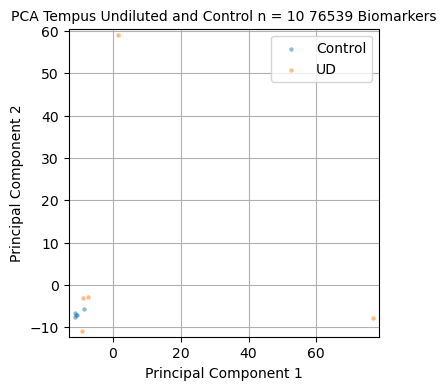

In [13]:
from plots.scatterPlots import createScatterPlot

def plotPCA(principalComponentsNP, XDF, metaDF):
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:cyan']
    fig, pannel = createScatterPlot(
        x = principalComponentsNP[:,0],
        y = principalComponentsNP[:,1],
    
        title = f'PCA Tempus Undiluted and Control n = {principalComponentsNP.shape[0]} {len(XDF.columns)} Biomarkers',
        xLabel = 'Principal Component 1',
        yLabel = 'Principal Component 2', 
        categories = metaDF.loc[:, "category"].values,
        # colors  = ['r',  'b'],
        colors = colors,
        figSize = (4,4), 
        #figSize = (10,10), 
        axisPaddingPrecentage = 0.02,
    )

    imgFilePath = imgOut + "/PCA.png"
    fig.savefig(imgFilePath, dpi=600, bbox_inches='tight', facecolor="white", transparent=True)
    print(f'saved image to {imgFilePath}')

plotPCA( principalComponentsNP, XDF, tempusSamplesMetaDF)

# UMAP

In [14]:
%%time
reducer = umap.UMAP()
UMAPEmbeddingNP = reducer.fit_transform(XScaledNP)
print(f'UMAPEmbeddingNP.shape : {UMAPEmbeddingNP.shape}')

/private/home/aedavids/miniconda3/envs/extraCellularRNA/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/private/home/aedavids/miniconda3/envs/extraCellularRNA/lib/python3.11/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


UMAPEmbeddingNP.shape : (10, 2)
CPU times: user 42.7 s, sys: 9.1 s, total: 51.8 s
Wall time: 11.2 s


xmin: -3.41611385345459 xMax : -1.5154213905334473
yMin: -1.124097466468811 yMax : 1.3072233200073242
df.shape : (10, 3)
saved image to /private/home/aedavids/extraCellularRNA/deconvolutionAnalysis/tempus/jupyterNotebooks/tempusClusterAnalysis.out/img/UMAP.png


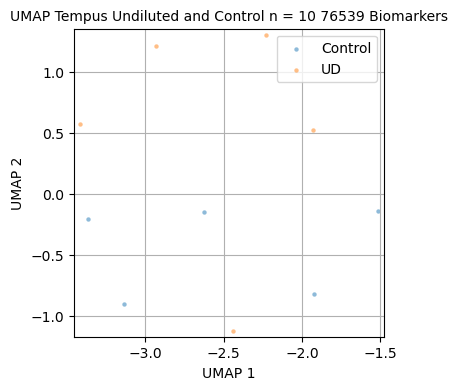

In [15]:
def plotUMAP(UMAPEmbeddingNP, XDF, metaDF) :
    '''
    TODO
    '''
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:cyan']


    fig, pannel = createScatterPlot(
        x = UMAPEmbeddingNP[:,0],
        y = UMAPEmbeddingNP[:,1],
        title = f'UMAP Tempus Undiluted and Control n = {UMAPEmbeddingNP.shape[0]} {len(XDF.columns)} Biomarkers',
        xLabel = 'UMAP 1',
        yLabel = 'UMAP 2', 
        categories = metaDF.loc[:, "category"].values,
        # colors  = ['r',  'b'],
        colors = colors,
        figSize = (4,4), 
        #figSize = (10,10), 
        #figSize = (15,15), 
        axisPaddingPrecentage = 0.02,
        #axisPaddingPrecentage = -0.01, # may clip some outliers
    )
    
    imgFilePath = imgOut + "/UMAP.png"
    fig.savefig(imgFilePath, dpi=600, bbox_inches='tight', facecolor="white", transparent=True)
    print(f'saved image to {imgFilePath}')

plotUMAP(UMAPEmbeddingNP, XDF, tempusSamplesMetaDF)

# TSNE

In [16]:
%%time
# https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html
# The perplexity is related to the number of nearest neighbors that is used in other manifold 
# learning algorithms. Larger datasets usually require a larger perplexity. Consider selecting a 
# value between 5 and 50. Different values can result in significantly different results. The 
# perplexity must be less than the number of samples.
perplexity = 3.0
TSNE_embedded = TSNE(perplexity=perplexity).fit_transform(XScaledNP)

CPU times: user 53.4 s, sys: 328 ms, total: 53.7 s
Wall time: 841 ms


xmin: -157.43577575683594 xMax : 157.7229461669922
yMin: -124.2765884399414 yMax : 114.86316680908203
df.shape : (10, 3)
saved image to /private/home/aedavids/extraCellularRNA/deconvolutionAnalysis/tempus/jupyterNotebooks/tempusClusterAnalysis.out/img/TSNE.png


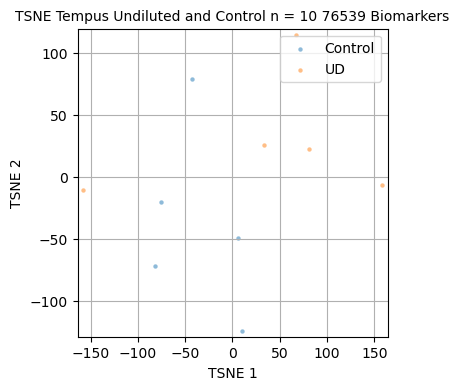

In [17]:
def plotTSNE(TSNE_embedded, XDF, metaDF) :
    '''
    TODO
    '''
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:cyan']


    fig, pannel = createScatterPlot(
        x = TSNE_embedded[:,0],
        y = TSNE_embedded[:,1],
        title = f'TSNE Tempus Undiluted and Control n = {TSNE_embedded.shape[0]} {len(XDF.columns)} Biomarkers',
        xLabel = 'TSNE 1',
        yLabel = 'TSNE 2', 
        categories = metaDF.loc[:, "category"].values,
        # colors  = ['r',  'b'],
        colors = colors,
        figSize = (4,4), 
        #figSize = (10,10), 
        #figSize = (15,15), 
        axisPaddingPrecentage = 0.02,
        #axisPaddingPrecentage = -0.01, # may clip some outliers
    )
    
    imgFilePath = imgOut + "/TSNE.png"
    fig.savefig(imgFilePath, dpi=600, bbox_inches='tight', facecolor="white", transparent=True)
    print(f'saved image to {imgFilePath}')

plotTSNE(TSNE_embedded, XDF, tempusSamplesMetaDF)